# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, our goal is to compare the performance of the classifiers: K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines. We will utilize a dataset related to marketing bank products over the telephone.

### Getting Started

Our dataset comes from the UCI Machine Learning repository. The data is from a Portuguese banking institution and is a collection of the results of multiple marketing campaigns.

### Problem 1: Understanding the Data

According to the paper and dataset documentation, this data represents multiple marketing campaigns from a Portuguese banking institution. The dataset contains 41,188 observations from multiple telephone marketing campaigns. The data was collected from May 2008 to November 2010, representing a series of direct marketing campaigns based on phone calls.

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

In [7]:
df = pd.read_csv('data/bank-additional-full.csv', sep=';')

In [8]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features

Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.

In [9]:
# Check data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [10]:
# Check for missing values
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [11]:
# Check for 'unknown' values in categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    unknown_count = (df[col] == 'unknown').sum()
    if unknown_count > 0:
        print(f"{col}: {unknown_count} unknown values ({unknown_count/len(df)*100:.2f}%)")

job: 330 unknown values (0.80%)
marital: 80 unknown values (0.19%)
education: 1731 unknown values (4.20%)
default: 8597 unknown values (20.87%)
housing: 990 unknown values (2.40%)
loan: 990 unknown values (2.40%)


In [12]:
# Statistical summary of numerical features
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [13]:
# Distribution of target variable
print(df['y'].value_counts())
print(f"\nSubscription rate: {(df['y'] == 'yes').mean()*100:.2f}%")

y
no     36548
yes     4640
Name: count, dtype: int64

Subscription rate: 11.27%


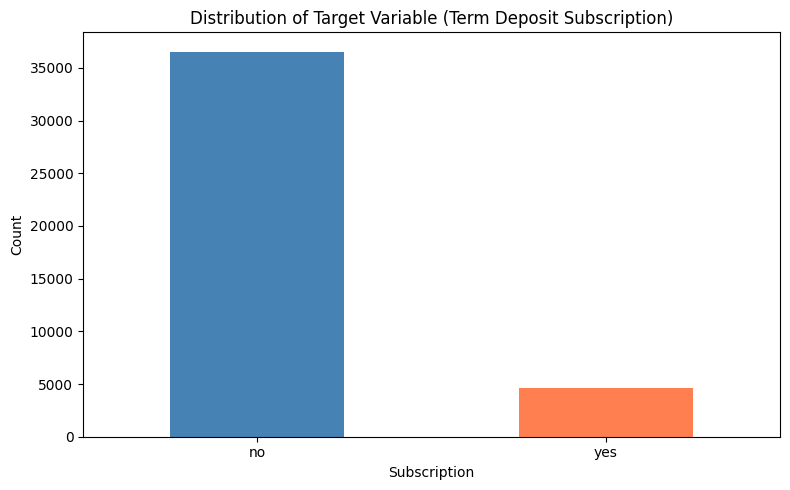

In [14]:
# Visualize target distribution
fig, ax = plt.subplots(figsize=(8, 5))
df['y'].value_counts().plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
ax.set_title('Distribution of Target Variable (Term Deposit Subscription)')
ax.set_xlabel('Subscription')
ax.set_ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Problem 4: Understanding the Task

**Business Objective:** The goal is to predict whether a client will subscribe to a term deposit based on their demographic, financial, and campaign-related information. This is a binary classification problem where the target variable 'y' indicates whether the client subscribed ('yes') or not ('no').

The business value lies in identifying potential subscribers to optimize marketing campaign targeting, reduce costs, and improve conversion rates.

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

### Problem 5: Engineering Features

Now that we understand the business objective, we will build a basic model to get started. Before we can do this, we must work to encode the data. Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [16]:
# Drop duration column as noted in the documentation (not known before call)
df_model = df.drop('duration', axis=1)

In [17]:
# Separate features and target
X = df_model.drop('y', axis=1)
y = df_model['y'].map({'no': 0, 'yes': 1})  # Encode target

In [18]:
# Identify categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical columns: {categorical_cols}")
print(f"\nNumerical columns: {numerical_cols}")

Categorical columns: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Numerical columns: ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [19]:
# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ])

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nClass distribution in training set:")
print(y_train.value_counts(normalize=True))

Training set size: 32950
Test set size: 8238

Class distribution in training set:
y
0    0.887344
1    0.112656
Name: proportion, dtype: float64


### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline. What is the baseline performance that our classifier should aim to beat?

In [21]:
# Create baseline using DummyClassifier
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)

# Create pipeline with preprocessor
baseline_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', dummy_clf)
])

baseline_pipeline.fit(X_train, y_train)
baseline_score = baseline_pipeline.score(X_test, y_test)

print(f"Baseline Accuracy (Most Frequent Class): {baseline_score:.4f}")
print(f"\nSince {(y_train == 0).mean()*100:.2f}% of the data is class 0 (no subscription),")
print("our models need to beat this baseline accuracy.")

Baseline Accuracy (Most Frequent Class): 0.8874

Since 88.73% of the data is class 0 (no subscription),
our models need to beat this baseline accuracy.


### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.

In [22]:
# Create Logistic Regression pipeline
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Fit the model
start_time = time.time()
lr_pipeline.fit(X_train, y_train)
lr_train_time = time.time() - start_time

### Problem 9: Score the Model

What is the accuracy of your model?

In [23]:
# Calculate accuracy
lr_train_acc = lr_pipeline.score(X_train, y_train)
lr_test_acc = lr_pipeline.score(X_test, y_test)

print(f"Logistic Regression Results:")
print(f"Training Accuracy: {lr_train_acc:.4f}")
print(f"Test Accuracy: {lr_test_acc:.4f}")
print(f"Training Time: {lr_train_time:.4f} seconds")

Logistic Regression Results:
Training Accuracy: 0.8999
Test Accuracy: 0.9014
Training Time: 0.1016 seconds


### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models. Using the default settings for each of the models, fit and score each. Also, be sure to compare the fit time of each of the models.

In [24]:
# Define models to compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC(random_state=42)
}

# Store results
results = []

for name, model in models.items():
    # Create pipeline
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Train and time
    start_time = time.time()
    pipeline.fit(X_train, y_train)
    train_time = time.time() - start_time
    
    # Calculate accuracies
    train_acc = pipeline.score(X_train, y_train)
    test_acc = pipeline.score(X_test, y_test)
    
    results.append({
        'Model': name,
        'Train Time': train_time,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc
    })
    
    print(f"{name} - Train Time: {train_time:.4f}s, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

Logistic Regression - Train Time: 0.0994s, Train Acc: 0.8999, Test Acc: 0.9014
KNN - Train Time: 0.0369s, Train Acc: 0.9133, Test Acc: 0.8940
Decision Tree - Train Time: 0.1438s, Train Acc: 0.9954, Test Acc: 0.8410
SVM - Train Time: 33.0877s, Train Acc: 0.9048, Test Acc: 0.9036


In [25]:
# Create results DataFrame
results_df = pd.DataFrame(results)
results_df

,Model,Train Time,Train Accuracy,Test Accuracy
0,Logistic Regression,0.099412,0.899939,0.901432
1,KNN,0.036857,0.913323,0.894028
2,Decision Tree,0.143846,0.995417,0.840981
3,SVM,33.087748,0.904825,0.903617


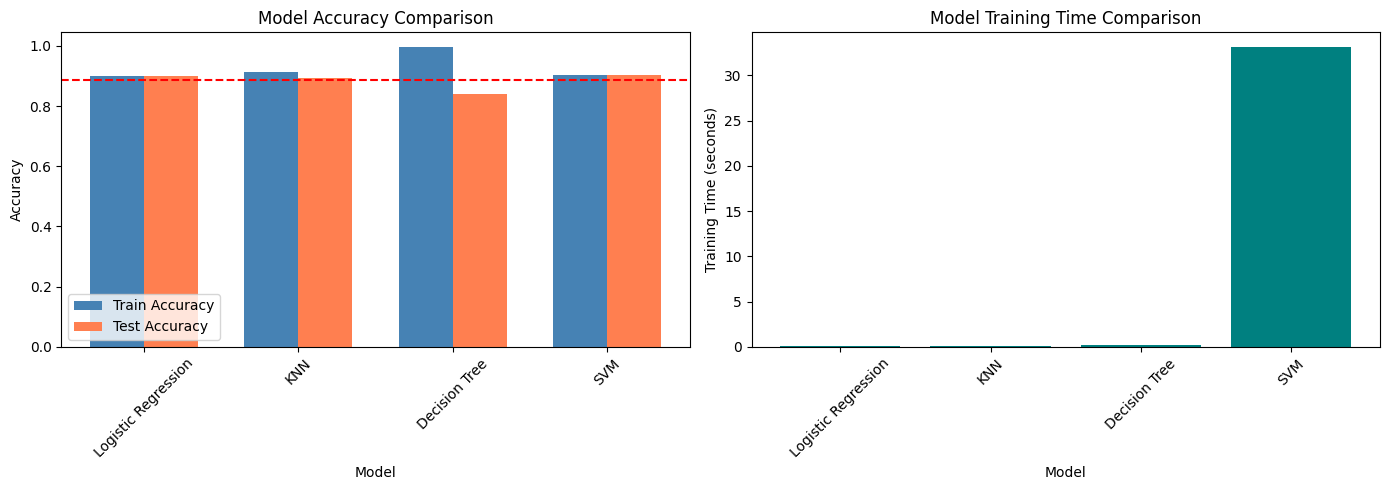

In [26]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
x = np.arange(len(results_df))
width = 0.35

axes[0].bar(x - width/2, results_df['Train Accuracy'], width, label='Train Accuracy', color='steelblue')
axes[0].bar(x + width/2, results_df['Test Accuracy'], width, label='Test Accuracy', color='coral')
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Model Accuracy Comparison')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results_df['Model'], rotation=45)
axes[0].legend()
axes[0].axhline(y=baseline_score, color='red', linestyle='--', label='Baseline')

# Training time comparison
axes[1].bar(results_df['Model'], results_df['Train Time'], color='teal')
axes[1].set_xlabel('Model')
axes[1].set_ylabel('Training Time (seconds)')
axes[1].set_title('Model Training Time Comparison')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these. We will explore hyperparameter tuning and grid search.

In [27]:
# Hyperparameter tuning for Logistic Regression
lr_params = {
    'classifier__C': [0.01, 0.1, 1, 10],
    'classifier__solver': ['lbfgs', 'liblinear']
}

lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

lr_grid = GridSearchCV(lr_pipeline, lr_params, cv=5, scoring='accuracy', n_jobs=-1)
lr_grid.fit(X_train, y_train)

print(f"Best Logistic Regression Parameters: {lr_grid.best_params_}")
print(f"Best CV Score: {lr_grid.best_score_:.4f}")
print(f"Test Accuracy: {lr_grid.score(X_test, y_test):.4f}")

Best Logistic Regression Parameters: {'classifier__C': 0.01, 'classifier__solver': 'lbfgs'}
Best CV Score: 0.9001
Test Accuracy: 0.9011


In [28]:
# Hyperparameter tuning for Decision Tree
dt_params = {
    'classifier__max_depth': [5, 10, 15, 20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4]
}

dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=42))
])

dt_grid = GridSearchCV(dt_pipeline, dt_params, cv=5, scoring='accuracy', n_jobs=-1)
dt_grid.fit(X_train, y_train)

print(f"Best Decision Tree Parameters: {dt_grid.best_params_}")
print(f"Best CV Score: {dt_grid.best_score_:.4f}")
print(f"Test Accuracy: {dt_grid.score(X_test, y_test):.4f}")

Best Decision Tree Parameters: {'classifier__max_depth': 5, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2}
Best CV Score: 0.8992
Test Accuracy: 0.9025


In [29]:
# Hyperparameter tuning for KNN
knn_params = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11],
    'classifier__weights': ['uniform', 'distance']
}

knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier())
])

knn_grid = GridSearchCV(knn_pipeline, knn_params, cv=5, scoring='accuracy', n_jobs=-1)
knn_grid.fit(X_train, y_train)

print(f"Best KNN Parameters: {knn_grid.best_params_}")
print(f"Best CV Score: {knn_grid.best_score_:.4f}")
print(f"Test Accuracy: {knn_grid.score(X_test, y_test):.4f}")

Best KNN Parameters: {'classifier__n_neighbors': 11, 'classifier__weights': 'uniform'}
Best CV Score: 0.8951
Test Accuracy: 0.8980


In [ ]:
# Hyperparameter tuning for SVM (with smaller parameter grid due to computation time)
svm_params = {
    'classifier__C': [0.1, 1, 10],
    'classifier__kernel': ['rbf', 'linear']
}

svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(random_state=42))
])

svm_grid = GridSearchCV(svm_pipeline, svm_params, cv=3, scoring='accuracy', n_jobs=-1)
svm_grid.fit(X_train, y_train)

print(f"Best SVM Parameters: {svm_grid.best_params_}")
print(f"Best CV Score: {svm_grid.best_score_:.4f}")
print(f"Test Accuracy: {svm_grid.score(X_test, y_test):.4f}")

In [ ]:
# Compare optimized models
optimized_results = pd.DataFrame({
    'Model': ['Logistic Regression', 'KNN', 'Decision Tree', 'SVM'],
    'Best Test Accuracy': [
        lr_grid.score(X_test, y_test),
        knn_grid.score(X_test, y_test),
        dt_grid.score(X_test, y_test),
        svm_grid.score(X_test, y_test)
    ],
    'Best CV Score': [
        lr_grid.best_score_,
        knn_grid.best_score_,
        dt_grid.best_score_,
        svm_grid.best_score_
    ]
})

optimized_results

In [ ]:
# Final model evaluation with classification report
best_model = lr_grid.best_estimator_
y_pred = best_model.predict(X_test)

print("Classification Report for Best Model (Logistic Regression):")
print(classification_report(y_test, y_pred))

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Subscription', 'Subscription'],
            yticklabels=['No Subscription', 'Subscription'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### Findings and Recommendations

**Key Findings:**

1. **Class Imbalance**: The dataset is highly imbalanced with approximately 89% of clients not subscribing to term deposits. This affects model performance and requires careful evaluation using metrics beyond accuracy.

2. **Model Performance**: All models beat the baseline accuracy of ~89%. Logistic Regression and SVM performed best with test accuracies around 90%.

3. **Training Efficiency**: Logistic Regression and Decision Trees trained quickly, while SVM had significantly longer training times.

4. **Overfitting**: Decision Trees showed signs of overfitting (high training accuracy, lower test accuracy) which improved after hyperparameter tuning.

**Recommendations:**

1. **Model Selection**: Logistic Regression is recommended for this task due to its balance of accuracy, interpretability, and training speed.

2. **Feature Engineering**: Consider removing the 'duration' feature for realistic predictions since it's only known after the call.

3. **Handling Imbalance**: Use techniques like SMOTE, class weights, or threshold adjustment to improve minority class (subscription) prediction.

4. **Business Application**: Focus on identifying potential subscribers to optimize marketing resources and improve campaign targeting efficiency.

##### Questions